# Animal Poster Demo

This notebook generates a poster of animal images with deterministic labels and layout.

The Phase 2 version keeps the notebook thin: the app function owns selection, image-cache resolution, optional generation, spec construction, and rendering. The notebook owns parameters and display.

## Setup

This notebook uses the shared `agentic_multimodal` package and creates a registry for common services.

In [1]:
from notebook_bootstrap import (
    display_image,
    image_files,
    init_notebook,
)

ctx, reg = init_notebook()

REPO_ROOT = ctx.repo_root
PROJECT_ROOT = ctx.project_root
SRC_ROOT = ctx.src_root
PACKAGE_SRC = ctx.package_src
CACHE = ctx.cache
RESULTS = ctx.results


/opt/anaconda3/envs/ai_py312/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
Repo root: /Users/douglasdaly/GitHub/Generative-AI
Project root: /Users/douglasdaly/GitHub/Generative-AI
Package src: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal
Cache: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal/cache
Results: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal
Legacy artifact roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/artifacts']
Legacy cache roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/cache']


## Demo parameters

Start small while developing. Larger posters work better once the image cache is warm.

In [2]:
from agentic_multimodal.apps.animal_poster import run_animal_poster

ANIMAL_COUNT = 10
ANIMAL_SEED = "animals_mix_v1"
POSTER_TITLE = f"{ANIMAL_COUNT} Animals"

# Heavy local image generation remains opt-in.
RUN_IMAGE_GENERATION = False

# The animal image cache uses generated filenames. The app resolves cached files
# by expected item slug rather than blindly joining sorted files to animals.
FAIL_ON_MISSING_IMAGES = True
ALLOW_POSITIONAL_CACHE_FALLBACK = False

IMAGE_SIZE = (512, 512)
STEPS = 24
CFG = 6.0
BATCH_SIZE = 5
TILE_SIZE = (768, 768)

ANIMAL_IMAGE_DIR = ctx.resolve_dir(
    f"animals_portraits_{ANIMAL_COUNT}",
    preferred_root=RESULTS,
    legacy_roots=ctx.artifact_roots,
)
ANIMAL_POSTER_PATH = RESULTS / "posters" / f"poster_animals_{ANIMAL_COUNT}_mixed.webp"

print("Animal image directory:", ANIMAL_IMAGE_DIR)
print("Animal poster path:", ANIMAL_POSTER_PATH)


Animal image directory: /Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/artifacts/animals_portraits_10
Animal poster path: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/posters/poster_animals_10_mixed.webp


## Run the app workflow

The app returns an `ArtifactResult`, which gives the notebook a consistent shape across all four demos.

animal_poster: 10 Animals (created) -> /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/posters/poster_animals_10_mixed.webp


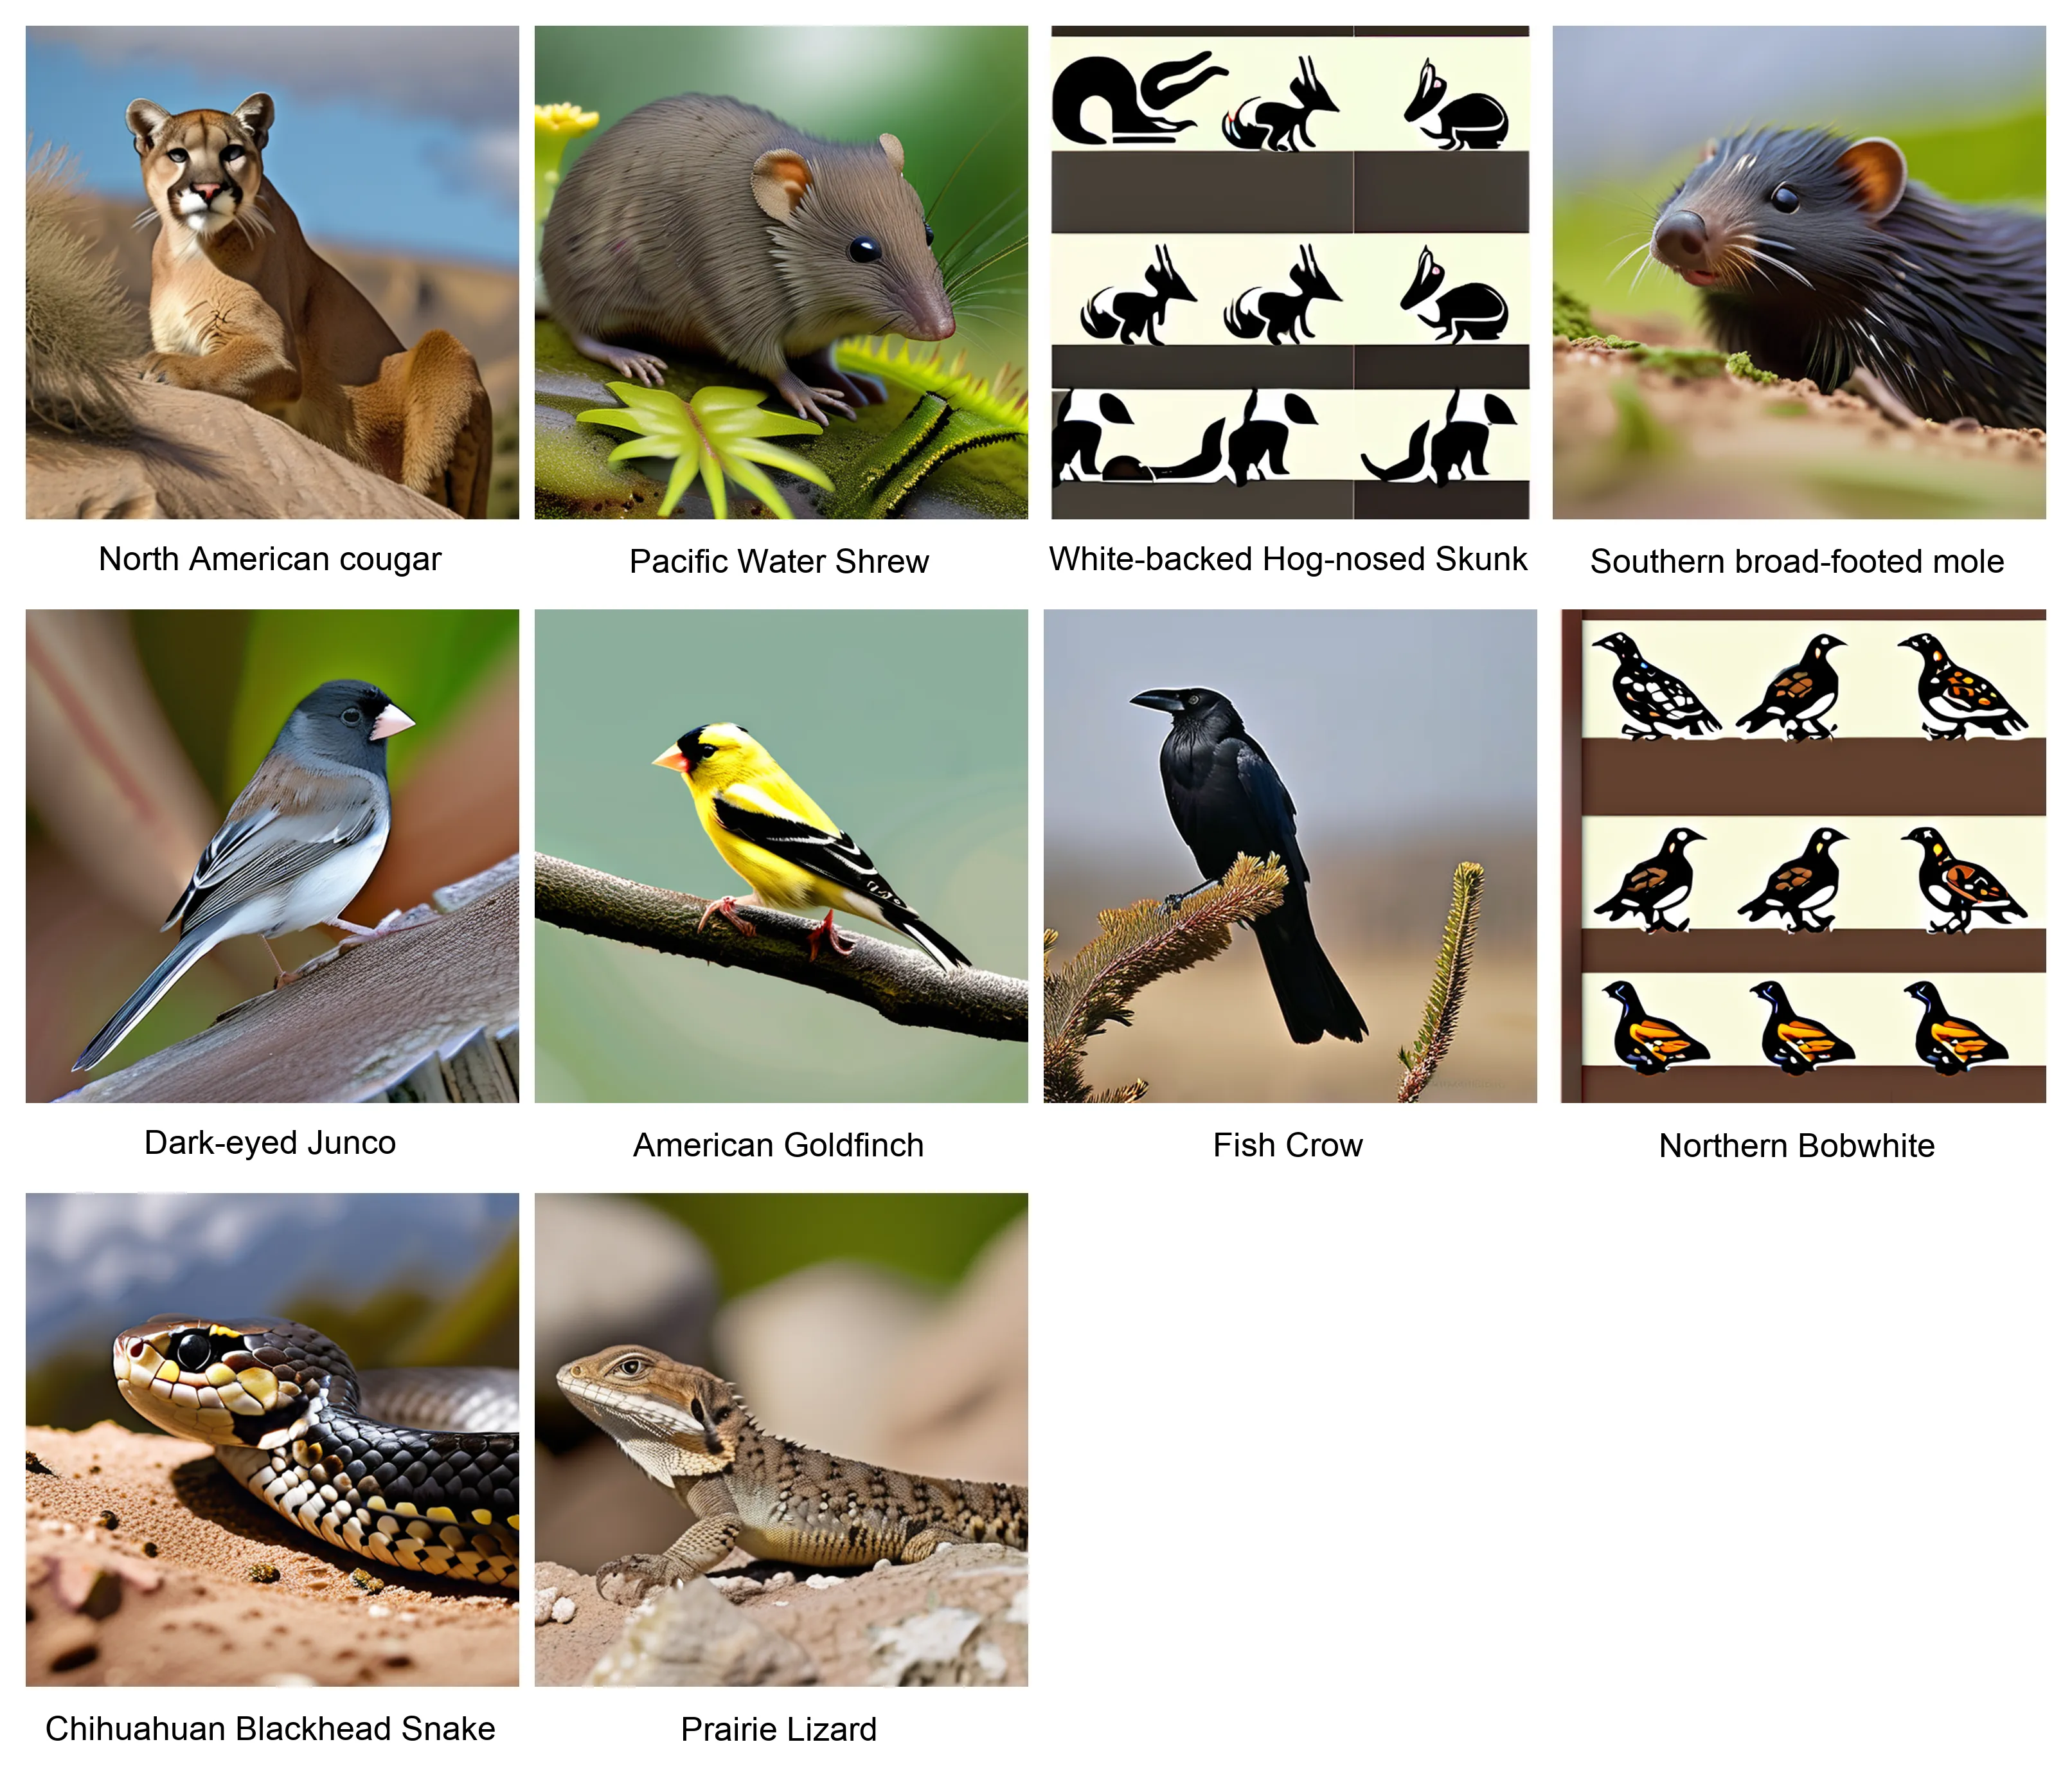

In [3]:
result = run_animal_poster(
    reg=reg,
    results_dir=RESULTS,
    animal_count=ANIMAL_COUNT,
    animal_seed=ANIMAL_SEED,
    title=POSTER_TITLE,
    run_image_generation=RUN_IMAGE_GENERATION,
    fail_on_missing_images=FAIL_ON_MISSING_IMAGES,
    allow_positional_cache_fallback=ALLOW_POSITIONAL_CACHE_FALLBACK,
    image_dir=ANIMAL_IMAGE_DIR,
    outpath=ANIMAL_POSTER_PATH,
    image_size=IMAGE_SIZE,
    steps=STEPS,
    cfg=CFG,
    batch_size=BATCH_SIZE,
    tile_size=TILE_SIZE,
)

print(result.summary())
display_image(result.path)


## Inspect result metadata

The trace captures item selection, image cache behavior, and render settings.

In [4]:
from pprint import pprint

pprint(result.to_dict())


{'cache_hits': {'cached_before': 10, 'resolved_images': 10},
 'cache_misses': {'generated_or_added': 0, 'missing_images': 0},
 'cache_summary': {'cached_after': 10,
                   'cached_before': 10,
                   'generated_or_added': 0,
                   'image_dir': '/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/artifacts/animals_portraits_10',
                   'missing': 0,
                   'resolved': 10,
                   'used_positional_fallback': False},
 'exists': True,
 'kind': 'animal_poster',
 'path': '/Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/posters/poster_animals_10_mixed.webp',
 'title': '10 Animals',
 'trace': {'allow_positional_cache_fallback': False,
           'animal_count': 10,
           'animal_seed': 'animals_mix_v1',
           'group_counts': {'bird': 4, 'mammal': 4, 'reptile': 2},
           'image_count': 10,
           'image_dir': '/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-mult

## Smoke checks

In [5]:
assert result.exists
assert result.kind == "animal_poster"
assert result.trace["animal_count"] == ANIMAL_COUNT
assert result.trace["item_count"] == ANIMAL_COUNT
assert result.trace["image_count"] == ANIMAL_COUNT

if FAIL_ON_MISSING_IMAGES:
    assert result.cache_summary["missing"] == 0

print("Animal poster app smoke checks passed.")


Animal poster app smoke checks passed.


## Optional: larger poster

Leave this off until the cache is warm or you intentionally want to generate more images.

In [6]:
RUN_LARGER_POSTER = False

if RUN_LARGER_POSTER:
    larger_result = run_animal_poster(
        reg=reg,
        results_dir=RESULTS,
        animal_count=25,
        animal_seed="animals_mix_v1",
        title="25 Animals",
        run_image_generation=False,
        fail_on_missing_images=True,
        image_dir=ctx.resolve_dir(
            "animals_portraits_25",
            preferred_root=RESULTS,
            legacy_roots=ctx.artifact_roots,
        ),
        outpath=RESULTS / "posters" / "poster_animals_25_mixed.webp",
        batch_size=BATCH_SIZE,
        tile_size=TILE_SIZE,
    )

    print(larger_result.summary())
    display_image(larger_result.path)


## Implementation notes

- The app uses the same shared poster renderer as the people-series workflow.
- Image generation remains explicit because it can be slow or expensive.
- Cached animal images are resolved by expected generated filename rather than by a naive sorted-file join.
- `ALLOW_POSITIONAL_CACHE_FALLBACK=True` exists only as a migration escape hatch for old caches. Keep it `False` for clean runs.
- A future improvement would be a manifest-backed animal image resolver, matching the stricter people-series image asset flow.